# Introduction

## Core Concept

An adaptive filter is an optimal filter, with the key difference that optimality is not computed in a one-off manner, but rather recursively,
meaning it gradually converges toward the optimal solution.

While static optimal filters are computed once and for all, in recursive (or block-recursive) approaches, 
the filter coefficients are continuously updated.

This makes them particularly useful for (slowly) non-stationary signals.

Historically, three distinct (though significantly overlapping) approaches have emerged for least-squares (LSE) optimal filters, 
each identified by different names:

## 1) Block Methods (LS – Least Squares)

These correspond to the methods previously referred to as “optimal filters.” They require simultaneous access to all known signal samples (a complete data block).
### Pros
* They work very well
* Good performance
### Cons
* High computational cost
* Significant delay (which is a consequence of the high computational cost)
  
For example, designing an optimal FIR filter requires solving a system of linear equations, i.e., inverting a matrix.
The computational complexity is at most proportional to the cube of the dimension, O(N³).

## 2) Recursive Methods (Online, LMS – Least Mean Squares)

At the opposite extreme of approach 1), fully recursive methods exist, where optimality is approached asymptotically: at each step, incremental computations are performed, and after processing a substantial portion of the signal, the optimal solution is reached.

<< Historically, this approach is known as LMS >>

Often categorized under “adaptive filters.” They do not require knowledge of the entire signal, only a small portion (even a single sample).


### Pros
* Low computational cost → complexity O(N)
* Fast execution
### Cons
* Convergence issues: optimality is not guaranteed to be reached and for sure not immediately.


## 3) Block-Recursive Methods (RLS – Recursive Least Squares)

These lie midway between approaches 1) and 2).

Require higher computational cost than LMS → complexity O(N²)
Lower delay compared to batch LS

## Notes about approaches
Methods 2) and 3) can also be applied to (slowly) non-stationary signals.
The below stated computational complexities are rough approximations (order-of-magnitude estimates), not exact values, but they provide a useful comparative perspective:

1) → O(N³)

2) → O(N)

3) → O(N²)

In the context of discrete-time signal processing, recursive algorithms are extensively used due:
* low computational cost;
* online adaptation capability, which enables tracking of non-stationarities.

Being inherently online, if the characteristics of the target system change (i.e., the optimal solution shifts), 
the filter gradually adapts to the new optimum → a critical feature for many practical applications.

In DSP applications, the LMS algorithm remains the most widely used.

# Adaptation Strategies

## Open-Loop (Blind)

There is considerable interest in blind strategies. In this approach, adaptation relies exclusively on the characteristics of the input signal. 
For example, if the objective is to obtain a whitened signal, we analyze the input spectrum, identify spectral coloration (e.g., “this region is colored and requires attenuation; that region is acceptable”), and implement the necessary compensation by adjusting the filter’s poles and zeros.

<img src="images/open_loop_operator_diagram.svg" style="width:50%">

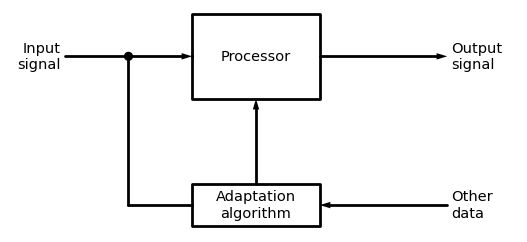

In [46]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.dsp as dsp
from schemdraw.util import Point

with schemdraw.Drawing(fontsize=12) as d:
    u = d.unit

    # ── Input signal → dot → Processor → Output (all chained, no .at) ──
    d += elm.Line().right(u/2).label('Input\nsignal', loc='left')
    dot = d.add(elm.Dot())
    d += elm.Arrow().right(u/2)
    proc = d.add(dsp.Box(w=3, h=2).anchor('W').label('Processor'))
    d += elm.Arrow().right(u).at(proc.E).label('Output\nsignal', loc='right')

    # ── Adaptation algorithm box, placed below Processor ────────────────
    adapt = d.add(dsp.Box(w=3, h=1).anchor('N').at((proc.S[0], proc.S[1]-2)).label('Adaptation\nalgorithm'))

    # arrow up into Processor's south anchor
    d += elm.Arrow().up().at(adapt.N).to(proc.S)

    # ── Branch wire: dot down, then across to adaptation box ─────────────
    d += elm.Line().down().at(dot.center).toy(adapt.W)
    d += elm.Line().tox(adapt.W)

    # ── "Other data" entering from the right ─────────────────────────────
    d.move_from(adapt.E, dx=u)
    d += elm.Arrow().left(u).label('Other\ndata', loc='right')

## Closed-Loop (Supervised)

This corresponds to the scenario already discussed, where the performance metric is derived from the error signal and the desired 
output signal must be available.

<img src="images/closed_loop_operator_diagram.svg" style="width:50%">

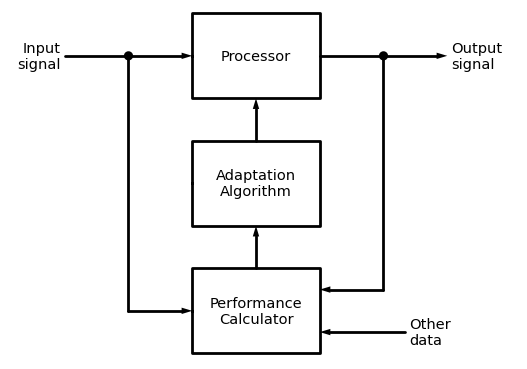

In [47]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.dsp as dsp

with schemdraw.Drawing(fontsize=12) as d:
    u = d.unit
    gap = 1.0  # vertical gap between stacked boxes — gives connecting arrows real length
    
    # ── Main signal path: Input → Processor → Output ──
    d += elm.Line().right(u/2).label('Input\nsignal', loc='left')
    dot_in = d.add(elm.Dot())
    d += elm.Arrow().right(u/2)
    proc = d.add(dsp.Box(w=3, h=2).anchor('W').label('Processor'))
    d += elm.Line().right(u/2).at(proc.E)
    dot_out = d.add(elm.Dot())
    d += elm.Arrow().right(u/2).label('Output\nsignal', loc='right')
   
    # ── Feedback chain below: Adaptation Algorithm → Performance Calculator ──
    adapt = d.add(dsp.Box(w=3, h=2).anchor('N')
                  .at((proc.S[0], proc.S[1] - gap))
                  .label('Adaptation\nAlgorithm'))
    d += elm.Arrow().at(adapt.N).to(proc.S)

    perf = d.add(dsp.Box(w=3, h=2).anchor('N')
                 .at((adapt.S[0], adapt.S[1] - gap))
                 .label('Performance\nCalculator'))
    d += elm.Arrow().at(perf.N).to(adapt.S)

    # ── Feedback taps into Performance Calculator ──
    d += elm.Line().down().at(dot_in.center).toy(perf.W)
    d += elm.Arrow().to(perf.W)

    perf_e_upper = (perf.E[0], perf.E[1] + 0.5)
    d += elm.Line().at(dot_out.center).to((dot_out.center[0], perf_e_upper[1]))
    d += elm.Arrow().to(perf_e_upper)

    # ── External input: Other data ──
    perf_e_lower = (perf.E[0], perf.E[1] - 0.5)
    d += (elm.Arrow().at((perf_e_lower[0] + 2, perf_e_lower[1]))
          .to(perf_e_lower)
          .label('Other\ndata', loc='right'))

### Closed-loop adaptation
The Adaptive Filters focus on this adaptive strategy.
The classic scheme is as follow:

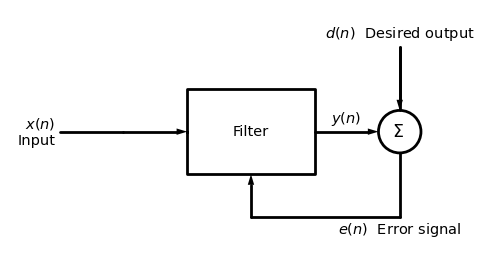

In [48]:
import schemdraw
import schemdraw.dsp as dsp

with schemdraw.Drawing(fontsize=12) as d:
    u = d.unit

    d += dsp.Line().right(u/2).label('$x(n)$\nInput', loc='left')
    d += dsp.Arrow().right(u/2)

    filt = d.add(dsp.Box(w=3, h=2).anchor('W').label('Filter'))

    d += dsp.Arrow().right(u/2).at(filt.E).label('$y(n)$', loc='top')
    sm = d.add(dsp.SumSigma())

    d += dsp.Line().down(u/2).at(sm.S).label('$e(n)$  Error signal', loc='left')
    d += dsp.Line().tox(filt.S)
    d += dsp.Arrow().toy(filt.S)

    d += dsp.Line().up(u/2).at(sm.N)
    d += dsp.Arrow().toy(sm.N).flip().label('$d(n)$  Desired output', loc='right')

The Filter Output (causal) is:

$$y[n] = \sum_{k=1}^{N} a_k y[n-k] + \sum_{k=0}^{M} b_k x[n-k]$$

Target Output $\equiv$ The ideal filter output: $d[n]$

Error signal $\equiv$ the delta between the Target Output and the Filter Output: $e[n] = d[n] - y[n]$

#### Adaptation in least square sense

Find $a_k$ ($k=1,...,N$) and $b_k$ ($k=0,...,M$) so that the power of the error signal $e(n)$ is the smallest possible

$$a_k, b_k \iff \min_{a_k,b_k} \{ \varepsilon^2 = E[e^2(n)] \}$$

In many of these problems, if we were to plot the error as a function of the parameters (feasible only in 1D and 2D cases), 
the error surface would take the shape of a paraboloid or hyperparaboloid (in higher dimensions) with a single 
minimum and convex curvature (bowl-shaped).

* The error is inherently quadratic, meaning it exhibits a quadratic dependence on the filter parameters.
* The error surface possesses a unique global minimum.

The objective is to locate this minimum. 
To do so, we employ a recursive algorithm: we begin at an arbitrary point (i.e., initialize the filter with random/arbitrary 
coefficients) and then iteratively update the solution: specifically update the filter coefficients until convergence to the minimum is reached.

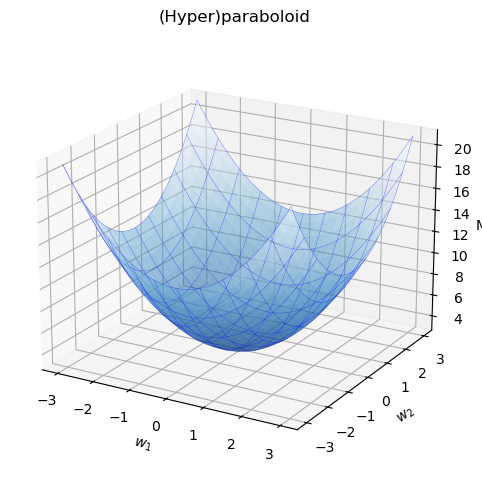

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D paraboloid
ax1 = fig.add_subplot(121, projection='3d')
w1 = np.linspace(-3, 3, 60)
w2 = np.linspace(-3, 3, 60)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 1*W2**2 + 3.0
ax1.plot_surface(W1, W2, Z, alpha=0.5, cmap='Blues_r', edgecolor='none')
ax1.plot_wireframe(W1, W2, Z, rstride=6, cstride=6, color='blue', linewidth=0.2, alpha=0.8)
ax1.set_xlabel('$w_1$'); ax1.set_ylabel('$w_2$'); ax1.set_zlabel('MSE')
ax1.set_title('(Hyper)paraboloid')
ax1.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

# Recursive Algorithm

**Problem:** Find the minimum of an N-dimensional quadratic function

$$\varepsilon = \varepsilon(\bar{x}) = \varepsilon(x_1, x_2, \ldots, x_{N-1}, x_N)$$

We want to find $\varepsilon_{min}$, i.e. the optimal parameter $\bar{x}_{opt}$.
The classic idea is the Steepest Descent Algorithm

## Steepest Descent Algorithm

The steepest descent is a recursive algorithm: we start from any solution, update it, and try to move in the direction of the optimum.

- **Initialization:**

$\bar{x}^{(0)}$ = any N-dimensional vector

- **Recursion:**

$$\bar{x}^{(k+1)} = \bar{x}^{(k)} + \mu \left[ -\nabla_{\bar{x}}^{(k)}(\varepsilon) \right] \qquad k = 0, 1, 2, \ldots$$

Where:
- $\bar{x}^{(k)}$ is the solution vector at step $k$
- $\nabla_{\bar{x}}^{(k)}(\varepsilon)$ is the gradient of $\varepsilon$ with respect to $\bar{x}^{(k)}$
- $\mu$ is a positive real constant called the **adaptation rate**

To understand how to proceed, for simplicity we consider the **one-dimensional case**:
$$\bar{x} = x_1 \quad \text{(scalar)}$$

### Mono Dimensional example